In [223]:
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Load Data

In [224]:
# load in cleaned dataset
train = pd.read_csv('data/train_cleaned.csv')
test = pd.read_csv('data/test_cleaned.csv')
y = train[["SalePrice"]]
test_ids = test['Id'] # for submit to kaggle

train.drop(columns=["Id","SalePrice"],inplace=True)
test.drop(columns=["Id"],inplace=True)

# train test split
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Selection

In [225]:
# stepwise AIC feature selection (compare to BIC, it can allow more features)
def stepwise_aic(X, y, initial_features=None):
    included = list(initial_features) if initial_features else []

    def aic_of(features):
        if not features:
            return np.inf
        return sm.OLS(y, sm.add_constant(X[features])).fit().aic

    current_aic = aic_of(included)

    while True:
        changed = False

        # forward
        excluded = list(set(X.columns) - set(included))
        add_candidates = {col: aic_of(included + [col]) for col in excluded}
        if add_candidates:
            best_add_feature = min(add_candidates, key=add_candidates.get)
            best_add_aic = add_candidates[best_add_feature]
        else:
            best_add_feature, best_add_aic = None, np.inf

        # backward
        remove_candidates = {col: aic_of([c for c in included if c != col]) for col in included}
        if remove_candidates:
            best_remove_feature = min(remove_candidates, key=remove_candidates.get)
            best_remove_aic = remove_candidates[best_remove_feature]
        else:
            best_remove_feature, best_remove_aic = None, np.inf

        # print best move
        best_move_aic = min(best_add_aic, best_remove_aic, current_aic)

        if best_move_aic < current_aic:
            if best_add_aic < best_remove_aic:
                included.append(best_add_feature)
                current_aic = best_add_aic
                changed = True
                print(f"Add    {best_add_feature:>20}, AIC = {best_add_aic:.2f}")
            else:
                included.remove(best_remove_feature)
                current_aic = best_remove_aic
                changed = True
                print(f"Remove {best_remove_feature:>20}, AIC = {best_remove_aic:.2f}")

        if not changed:
            print("AIC Done! #feature = ", len(included))
            break

    return included

In [226]:
included = stepwise_aic(X_train,y_train)

Add             OverallQual, AIC = 28488.02
Add               GrLivArea, AIC = 28192.60
Add              BsmtFinSF1, AIC = 28069.49
Add              GarageCars, AIC = 27960.48
Add               ExterQual, AIC = 27885.89
Add         MSSubClass_freq, AIC = 27826.35
Add            BsmtExposure, AIC = 27765.73
Add             KitchenQual, AIC = 27741.25
Add       Neighborhood_freq, AIC = 27714.19
Add             FireplaceQu, AIC = 27698.95
Add         Condition1_freq, AIC = 27683.66
Add              Functional, AIC = 27672.97
Add                 LotArea, AIC = 27663.90
Add              GarageCond, AIC = 27655.59
Add             OverallCond, AIC = 27646.99
Add        No. of bathrooms, AIC = 27637.58
Add          RoofStyle_freq, AIC = 27630.21
Add           BldgType_freq, AIC = 27622.58
Add                BsmtQual, AIC = 27616.52
Add                BsmtCond, AIC = 27606.83
Add              HouseStyle, AIC = 27600.09
Add              MasVnrArea, AIC = 27592.66
Add      MasVnrType_BrkFace, AIC

In [227]:
# using selected features
X_train_aic = X_train[included]
X_test_aic = X_test[included]
test_aic = test[included]

<Axes: >

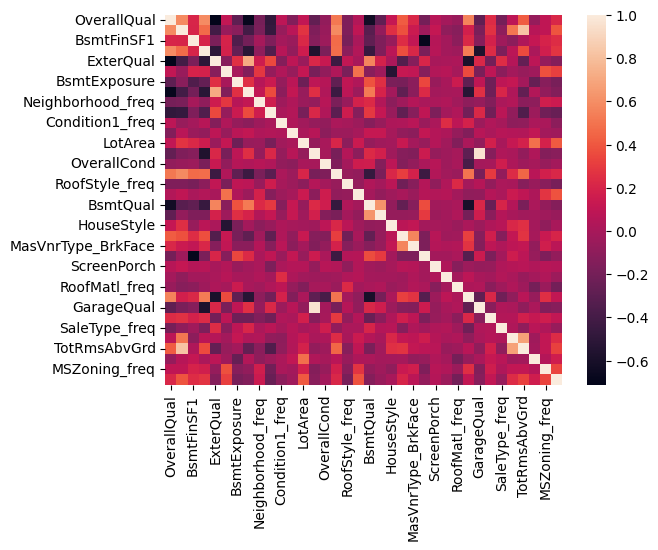

In [228]:
# this is for further removing the feature by correlation
corr = X_train_aic.corr()
sns.heatmap(corr)

In [229]:
# # triangle matrix for delete
# corr = X_train.corr().abs()
# upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# # columns to drop
# to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]
# print(to_drop)
# X_train_corr = X_train.drop(columns=to_drop)
# X_test_corr = X_test.drop(columns=to_drop)
# test_corr = test.drop(columns=to_drop)

In [230]:
# # corr after
# corr = X_train_corr.corr()
# sns.heatmap(corr)

### Train Model

In [231]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [232]:
# Linear Regression
model = LinearRegression()

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.25584082730484886
R^2:  0.8463087351750634

With log transformation
0.14941624977821522
R^2:  0.8803672373540974


In [233]:
# Decision Tree
model = DecisionTreeRegressor(random_state=42)

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.20962947646760036
R^2:  0.7343809729300311

With log transformation
0.2039263381024547
R^2:  0.7771554062605186


In [234]:
# Random Forest
model = RandomForestRegressor(random_state=42)

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.15037906023853911
R^2:  0.8872672638720708

With log transformation
0.14918367969729543
R^2:  0.880739304963448


In [235]:
# XGBoost without hyperparameter tuning
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.1493038319394576
R^2:  0.8931635618209839

With log transformation
0.1486324736382009
R^2:  0.8816190361976624


In [236]:
import optuna


def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0, step=0.05),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0, step=0.05),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.8, 1.2, step=0.05),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5, step=0.05),
        'gamma': trial.suggest_float('gamma', 0.0, 0.2, step=0.05),
        'learning_rate': 0.1,
        'n_estimators': 300,
        'random_state': 42,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train_aic, y_train)
    y_pred = model.predict(X_test_aic)
    rmse_log = np.sqrt(mean_squared_error(np.log(y_test), np.log(y_pred)))
    return rmse_log


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200, n_jobs=-1)

best_params = study.best_trial.params
print("Best RMSE(log):", study.best_value)
print("Best hyperparameters:", best_params)

[I 2025-11-14 16:20:46,266] A new study created in memory with name: no-name-a4e0b0ee-e238-44f1-b92f-e023fd1eb917
[I 2025-11-14 16:20:47,998] Trial 1 finished with value: 0.1374382704105616 and parameters: {'max_depth': 4, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.8, 'reg_lambda': 1.2, 'reg_alpha': 0.2, 'gamma': 0.15000000000000002}. Best is trial 1 with value: 0.1374382704105616.
[I 2025-11-14 16:20:48,198] Trial 2 finished with value: 0.1360334249743664 and parameters: {'max_depth': 5, 'subsample': 0.9500000000000001, 'colsample_bytree': 1.0, 'reg_lambda': 1.1500000000000001, 'reg_alpha': 0.4, 'gamma': 0.1}. Best is trial 2 with value: 0.1360334249743664.
[I 2025-11-14 16:20:48,957] Trial 4 finished with value: 0.1376175559431737 and parameters: {'max_depth': 6, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.8, 'reg_lambda': 1.1, 'reg_alpha': 0.2, 'gamma': 0.0}. Best is trial 2 with value: 0.1360334249743664.
[I 2025-11-14 16:20:49,204] Trial 0 finished with valu

Best RMSE(log): 0.129114185587568
Best hyperparameters: {'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_lambda': 0.8, 'reg_alpha': 0.15000000000000002, 'gamma': 0.05}


In [237]:
# XGBoost with hyperparameter tuning
model = xgb.XGBRegressor(**best_params, objective='reg:squarederror', learning_rate=0.1, n_estimators=1000, random_state=42)

reg = model.fit(X_train_aic, y_train, eval_set=[(X_train_aic, y_train),(X_test_aic, y_test)], verbose=False)
y_pred = reg.predict(X_test_aic)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

0.13196349860385603
R^2:  0.9254666566848755


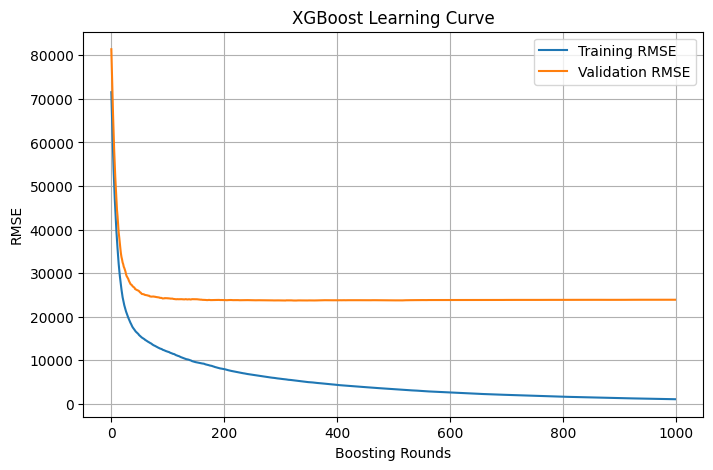

In [238]:
# XGBoost with hyperparameter tuning
results = reg.evals_result()

# Simple learning curve plot (validation RMSE over boosting rounds)
plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['rmse'], label='Training RMSE')
plt.plot(results['validation_1']['rmse'], label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

In [239]:
# XGBoost with hyperparameter tuning
model = xgb.XGBRegressor(**best_params, objective='reg:squarederror', learning_rate=0.1, n_estimators=300, random_state=42)

reg = model.fit(X_train_aic, y_train, eval_set=[(X_train_aic, y_train),(X_test_aic, y_test)], verbose=False)
y_pred = reg.predict(X_test_aic)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

0.129114185587568
R^2:  0.9264867901802063


In [240]:
test_pred = model.predict(test_aic)
submission_df = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_pred
})
submission_df.to_csv("data/submission.csv", index=False)